# Blood Glucose Level Prediction — FYP Practice Guide
### BRIST1D Dataset | XGBoost Regression | Non-Invasive Features (HR + Steps)

---

This notebook walks you **step-by-step** through the full ML pipeline:

1. Data Loading & Inspection
2. Cleaning & Preprocessing
3. Feature Engineering (lag + rolling features)
4. Per-Participant (Personalized) Modelling
5. Train / Validation Split
6. XGBoost Regression Training
7. Prediction & Results
8. Performance Statistics & Visualizations

> **FYP Scope:** Only `hr-*` (heart rate) and `steps-*` columns are used as input features.  
> `bg-*` columns are **excluded** (non-invasive assumption — we do not know BG at prediction time).  
> Target: `bg+1:00` — blood glucose 1 hour ahead.

---
## Step 0 — Install & Import Libraries

In [ ]:
# Run this cell once to install if needed
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 1 — Load the Data

In [2]:
# ── Change this path to wherever your train.csv lives ──
DATA_PATH = 'data/brist1d/train.csv'

df_raw = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df_raw.shape}")
print(f"\nParticipants: {df_raw['p_num'].unique()}")
print(f"Rows per participant:\n{df_raw['p_num'].value_counts()}")

Dataset shape: (177024, 508)

Participants: <StringArray>
['p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p10', 'p11', 'p12']
Length: 9, dtype: str
Rows per participant:
p_num
p03    26028
p02    25872
p10    25454
p12    25299
p04    24686
p11    24555
p01     8459
p06     8383
p05     8288
Name: count, dtype: int64


In [3]:
# Quick look at the first few rows
df_raw.head(3)

,id,p_num,time,bg-5:55,bg-5:50,bg-5:45,bg-5:40,bg-5:35,bg-5:30,bg-5:25,...,activity-0:40,activity-0:35,activity-0:30,activity-0:25,activity-0:20,activity-0:15,activity-0:10,activity-0:05,activity-0:00,bg+1:00
0,p01_0,p01,06:10:00,NaN,NaN,9.6,NaN,NaN,9.7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.4
1,p01_1,p01,06:25:00,NaN,NaN,9.7,NaN,NaN,9.2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.8
2,p01_2,p01,06:40:00,NaN,NaN,9.2,NaN,NaN,8.7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.5


In [4]:
# What column groups do we have?
hr_cols    = [c for c in df_raw.columns if c.startswith('hr-')]
steps_cols = [c for c in df_raw.columns if c.startswith('steps-')]
bg_cols    = [c for c in df_raw.columns if c.startswith('bg-')]  # excluded from input
TARGET     = 'bg+1:00'

print(f"HR columns    : {len(hr_cols)}  (e.g. {hr_cols[0]} … {hr_cols[-1]})")
print(f"Steps columns : {len(steps_cols)}  (e.g. {steps_cols[0]} … {steps_cols[-1]})")
print(f"BG-lag columns: {len(bg_cols)}  (EXCLUDED — invasive)")
print(f"Target        : {TARGET}")

HR columns    : 72  (e.g. hr-5:55 … hr-0:00)
Steps columns : 72  (e.g. steps-5:55 … steps-0:00)
BG-lag columns: 72  (EXCLUDED — invasive)
Target        : bg+1:00


---
## Step 2 — Data Cleaning & Preprocessing

The dataset already has lag features built in (e.g. `hr-0:05`, `hr-1:00`, etc.).  
Our cleaning tasks are:
- Drop rows where the target is missing
- Understand and handle NaN values in hr/steps columns
- Convert `time` into useful numeric features

Average missing % across HR columns   : 29.1%
Average missing % across Steps columns: 53.9%
Target missing rows                   : 0


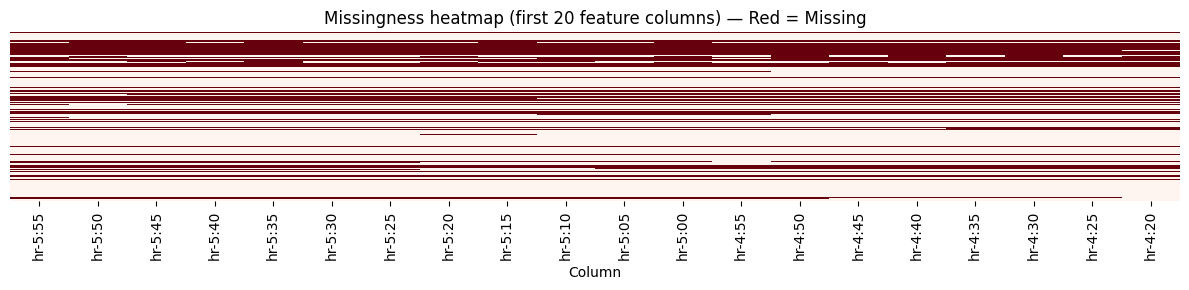

In [5]:
# ── Missing value summary ──
feature_cols = hr_cols + steps_cols

missing_pct = df_raw[feature_cols].isnull().mean() * 100
print(f"Average missing % across HR columns   : {missing_pct[hr_cols].mean():.1f}%")
print(f"Average missing % across Steps columns: {missing_pct[steps_cols].mean():.1f}%")
print(f"Target missing rows                   : {df_raw[TARGET].isnull().sum()}")

# Visualise missingness pattern (first 20 feature cols as a sample)
fig, ax = plt.subplots(figsize=(12, 3))
sample_miss = df_raw[feature_cols[:20]].isnull().astype(int)
sns.heatmap(sample_miss, cbar=False, cmap='Reds', ax=ax, yticklabels=False)
ax.set_title('Missingness heatmap (first 20 feature columns) — Red = Missing')
ax.set_xlabel('Column')
plt.tight_layout()
plt.show()

In [6]:
# ── Clean: Drop rows with missing target ──
print(f"Rows before dropping missing target: {len(df_raw)}")
df = df_raw.dropna(subset=[TARGET]).copy()
print(f"Rows after dropping missing target: {len(df)}")

# ── Parse time into seconds-since-midnight ──
# This lets the model learn time-of-day patterns (e.g. dawn phenomenon)
df['time_seconds'] = pd.to_timedelta(df['time']).dt.total_seconds()

# ── Sort by participant and time — important for time-series integrity ──
df = df.sort_values(['p_num', 'time_seconds']).reset_index(drop=True)

print("Time feature added. Data sorted by participant + time.")
df[['p_num', 'time', 'time_seconds']].head()

Rows before dropping missing target: 177024
Rows after dropping missing target: 177024
Time feature added. Data sorted by participant + time.


,p_num,time,time_seconds
0,p01,00:00:00,0.0
1,p01,00:00:00,0.0
2,p01,00:00:00,0.0
3,p01,00:00:00,0.0
4,p01,00:00:00,0.0


---
## Step 3 — Feature Engineering

The dataset already gives us **pre-computed lag columns** going back 6 hours (every 5 minutes).  
We'll use the most recent window (e.g. last 1 hour = 12 readings) as our primary lag features.  
On top of that, we compute **rolling statistics** (mean, std, max) over recent windows.

> **Why rolling features?**  
> A rolling mean over the last 30 min of HR tells the model your *average exertion level*,  
> while a rolling std tells it how *variable* your heart rate has been — both clinically meaningful.

In [7]:
def time_str_to_minutes(col_name, prefix):
    """Converts 'hr-1:30' → 90.0 minutes. Used to sort lag columns by recency."""
    lag_str = col_name.replace(prefix + '-', '')  # e.g. '1:30'
    h, m = lag_str.split(':')
    return int(h) * 60 + int(m)

# Sort HR and steps lag columns from most-recent (0:00) to oldest
hr_cols_sorted    = sorted(hr_cols,    key=lambda c: time_str_to_minutes(c, 'hr'))
steps_cols_sorted = sorted(steps_cols, key=lambda c: time_str_to_minutes(c, 'steps'))

print("HR lag columns ordered by recency (first=most recent):")
print(hr_cols_sorted[:6], '...', hr_cols_sorted[-3:])

HR lag columns ordered by recency (first=most recent):
['hr-0:00', 'hr-0:05', 'hr-0:10', 'hr-0:15', 'hr-0:20', 'hr-0:25'] ... ['hr-5:45', 'hr-5:50', 'hr-5:55']


In [11]:
# ── Select lag window: last N columns = most recent N readings ──
# Each step = 5 minutes. 12 steps = 1 hour lookback.
# You can experiment with 6 (30 min), 12 (1hr), 24 (2hr), 36 (3hr)

LOOKBACK_STEPS = 12  # 12 × 5min = 1 hour lookback

hr_lag_features    = hr_cols_sorted[:LOOKBACK_STEPS]     # most recent 12
steps_lag_features = steps_cols_sorted[:LOOKBACK_STEPS]

print(f"Using {LOOKBACK_STEPS} lag steps = {LOOKBACK_STEPS * 5} minute lookback")
print(f"HR lags used   : {hr_lag_features}")
print(f"Steps lags used: {steps_lag_features}")

Using 12 lag steps = 60 minute lookback
HR lags used   : ['hr-0:00', 'hr-0:05', 'hr-0:10', 'hr-0:15', 'hr-0:20', 'hr-0:25', 'hr-0:30', 'hr-0:35', 'hr-0:40', 'hr-0:45', 'hr-0:50', 'hr-0:55']
Steps lags used: ['steps-0:00', 'steps-0:05', 'steps-0:10', 'steps-0:15', 'steps-0:20', 'steps-0:25', 'steps-0:30', 'steps-0:35', 'steps-0:40', 'steps-0:45', 'steps-0:50', 'steps-0:55']


In [12]:
def build_rolling_features(df, col_list, prefix, windows=[3, 6, 12]):
    """
    Computes rolling mean, std, and max across pre-computed lag columns.
    
    Since the lag columns are already in the dataset (not a time-series index),
    we treat each row's lag values as a sequence and compute stats across them.
    
    windows: number of recent lag steps to summarize
             e.g. window=6 → statistics over the last 30 minutes
    """
    new_features = {}
    
    for w in windows:
        # Take the most recent `w` columns (already sorted by recency)
        window_cols = col_list[:w]
        window_data = df[window_cols]
        
        new_features[f'{prefix}_roll_mean_{w*5}min'] = window_data.mean(axis=1)
        new_features[f'{prefix}_roll_std_{w*5}min']  = window_data.std(axis=1)
        new_features[f'{prefix}_roll_max_{w*5}min']  = window_data.max(axis=1)
        new_features[f'{prefix}_roll_min_{w*5}min']  = window_data.min(axis=1)
    
    return pd.DataFrame(new_features, index=df.index)


# Build rolling features for HR and steps
hr_rolling    = build_rolling_features(df, hr_lag_features,    prefix='hr',    windows=[3, 6, 12])
steps_rolling = build_rolling_features(df, steps_lag_features, prefix='steps', windows=[3, 6, 12])

print("Rolling features created:")
print(list(hr_rolling.columns))
print(list(steps_rolling.columns))

Rolling features created:
['hr_roll_mean_15min', 'hr_roll_std_15min', 'hr_roll_max_15min', 'hr_roll_min_15min', 'hr_roll_mean_30min', 'hr_roll_std_30min', 'hr_roll_max_30min', 'hr_roll_min_30min', 'hr_roll_mean_60min', 'hr_roll_std_60min', 'hr_roll_max_60min', 'hr_roll_min_60min']
['steps_roll_mean_15min', 'steps_roll_std_15min', 'steps_roll_max_15min', 'steps_roll_min_15min', 'steps_roll_mean_30min', 'steps_roll_std_30min', 'steps_roll_max_30min', 'steps_roll_min_30min', 'steps_roll_mean_60min', 'steps_roll_std_60min', 'steps_roll_max_60min', 'steps_roll_min_60min']


In [49]:
# ── Assemble the full feature matrix ──
df_features = pd.concat([
    df[['p_num', 'time_seconds']],
    df[hr_lag_features],
    df[steps_lag_features],
    hr_rolling,
    steps_rolling,
], axis=1)

# ── Convert target from mmol/L to mg/dL ──
df_features[TARGET] = df[TARGET] * 18.018
print(f"Target converted to mg/dL (factor: 18.018)")

print(f"Feature matrix shape: {df_features.shape}")
print(f"\nFeatures breakdown:")
print(f"  HR lag features     : {len(hr_lag_features)}")
print(f"  Steps lag features  : {len(steps_lag_features)}")
print(f"  HR rolling features : {len(hr_rolling.columns)}")
print(f"  Steps rolling feats : {len(steps_rolling.columns)}")

print(f"  Time-of-day feature : 1")

print(f"  Total input features: {df_features.shape[1] - 2}")  # minus p_num and target
df_features.head(3)

Target converted to mg/dL (factor: 18.018)
Feature matrix shape: (177024, 51)

Features breakdown:
  HR lag features     : 12
  Steps lag features  : 12
  HR rolling features : 12
  Steps rolling feats : 12
  Time-of-day feature : 1
  Total input features: 49


,p_num,time_seconds,hr-0:00,hr-0:05,hr-0:10,hr-0:15,hr-0:20,hr-0:25,hr-0:30,hr-0:35,...,steps_roll_min_15min,steps_roll_mean_30min,steps_roll_std_30min,steps_roll_max_30min,steps_roll_min_30min,steps_roll_mean_60min,steps_roll_std_60min,steps_roll_max_60min,steps_roll_min_60min,bg+1:00
0,p01,0.0,78.1,73.6,74.2,70.6,70.1,64.4,61.8,66.0,...,16.0,28.000000,25.58906,76.0,8.0,14.333333,22.418877,76.0,0.0,95.4954
1,p01,0.0,65.2,65.0,61.1,59.5,79.9,63.0,64.6,67.8,...,0.0,4.833333,8.01041,19.0,0.0,9.083333,13.200953,41.0,0.0,91.8918
2,p01,0.0,62.2,61.9,58.3,57.2,58.9,64.7,66.6,67.3,...,0.0,0.000000,0.00000,0.0,0.0,18.666667,30.352100,83.0,0.0,75.6756


### ⚙️ Time Feature Engineering — Comparison Setup

The code below allows you to **easily switch between different time feature representations** to compare their impact on model performance:

- **`'linear'`** → Uses `time_seconds` directly (baseline, what you had before)
- **`'cyclic'`** → Uses sine/cosine encoding (captures 24-hour circadian patterns)
- **`'both'`** → Uses both together (for maximum expressiveness)

**To experiment:** Change the `TIME_FEATURE_TYPE` variable below, then re-run all cells. The model will automatically use the new time features and you can compare performance metrics across runs.

In [56]:

# ── Time Feature Engineering — Modular Approach ──
def build_time_features(time_seconds, feature_type='linear'):
    """
    Build time-of-day features from seconds-since-midnight.
    
    Parameters:
    -----------
    time_seconds : Series
        Seconds since midnight (0 to 86400)
    feature_type : str
        'linear'  → just time_seconds (baseline)
        'cyclic'  → sine/cosine encoding (captures 24h periodicity)
        'both'    → both linear AND cyclic (for comparison)
    
    Returns:
    --------
    DataFrame with time features
    """
    df_time = pd.DataFrame(index=time_seconds.index)
    
    if feature_type in ['linear', 'both']:
        df_time['time_seconds'] = time_seconds
    
    if feature_type in ['cyclic', 'both']:
        # Cyclic encoding: converts time to unit circle
        # 0:00 → (sin=0, cos=1)
        # 6:00 → (sin=1, cos=0)
        # 12:00 → (sin=0, cos=-1)
        # 18:00 → (sin=-1, cos=0)
        df_time['time_sin'] = np.sin(2 * np.pi * time_seconds / 86400)
        df_time['time_cos'] = np.cos(2 * np.pi * time_seconds / 86400)
    
    return df_time

# ── Choose time feature type here ──
# Options: 'linear', 'cyclic', 'both'
TIME_FEATURE_TYPE = 'cyclic'

time_features = build_time_features(df['time_seconds'], feature_type=TIME_FEATURE_TYPE)
print(f"Time features type: {TIME_FEATURE_TYPE}")
print(f"Columns generated: {list(time_features.columns)}")
time_features.head(3)

# update feature matrix with time features
df_features = pd.concat([df_features, time_features], axis=1)
print(f"Updated feature matrix shape: {df_features.shape}")

Time features type: cyclic
Columns generated: ['time_sin', 'time_cos']
Updated feature matrix shape: (177024, 53)


---
## Step 4 — Per-Participant (Personalized) Modelling

Since your FYP is about **personalized** BG prediction, we train a separate XGBoost model for each participant.  
This is the cleanest approach: each person's physiology is unique, so their model learns from their data only.

> **Alternative later:** You could also try a global model (all participants) vs. personalized — good FYP comparison!

In [57]:
# ── Define input feature columns ──
TIME_FEATURE_NAMES = list(time_features.columns)

FEATURE_COLS = (
    TIME_FEATURE_NAMES
    + hr_lag_features
    + steps_lag_features
    + list(hr_rolling.columns)
    + list(steps_rolling.columns)
)

print(f"Time features included: {TIME_FEATURE_NAMES}")
print(f"Total input features: {len(FEATURE_COLS)}")

Time features included: ['time_sin', 'time_cos']
Total input features: 50


## 🔄 Comparison Workflow

To compare linear vs. cyclic time features:

1. **Run A:** Keep `TIME_FEATURE_TYPE = 'linear'` (current baseline)
   - Note the validation R² and MAE for each participant
   
2. **Run B:** Change to `TIME_FEATURE_TYPE = 'cyclic'` 
   - Scroll up to the cell with `TIME_FEATURE_TYPE = 'linear'` and modify it
   - Re-run cells from "Time Feature Engineering" onwards
   - Compare validation metrics

3. **Run C (optional):** Try `TIME_FEATURE_TYPE = 'both'`
   - Compare all three approaches side-by-side

**Hypothesis:** Cyclic encoding may better capture dawn phenomenon (morning BG spike) since sine/cosine represent 24-hour patterns, whereas raw seconds are just a linear trend.

In [58]:
def prepare_participant_data(df_p, feature_cols, target):
    """
    For one participant's dataframe:
    - Drops rows where ALL hr or steps features are NaN (nothing to learn from)
    - Fills remaining NaNs with column median (simple imputation)
    - Returns X (features) and y (target)
    """
    # Drop rows where the majority of hr/steps lags are missing
    hr_feat   = [c for c in feature_cols if c.startswith('hr-')]
    step_feat = [c for c in feature_cols if c.startswith('steps-')]
    
    # Drop rows where all hr lag values AND all steps lag values are NaN
    all_nan_mask = df_p[hr_feat].isnull().all(axis=1) & df_p[step_feat].isnull().all(axis=1)
    df_clean = df_p[~all_nan_mask].copy()
    
    # Impute remaining NaNs with column median
    df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].median())
    
    X = df_clean[feature_cols]
    y = df_clean[target]
    
    return X, y, df_clean


print("Data preparation function defined.")

Data preparation function defined.


---
## Step 5 — Train / Validation Split

⚠️ **Important:** Because this is time-series data, we must NOT shuffle before splitting.  
We always use the **earlier data for training** and **later data for validation**.  
Shuffling would cause data leakage (future readings leaking into training).

In [59]:
def time_series_split(X, y, test_size=0.2):
    """
    Splits X and y maintaining time order.
    First 80% = train, last 20% = validation.
    NO shuffling — this is time-series data.
    """
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]
    return X_train, X_val, y_train, y_val

print("Time-series split function defined.")

Time-series split function defined.


---
## Step 6 — XGBoost Model Training

We train one XGBoost model per participant and store the results.

In [60]:
# XGBoost hyperparameters — good starting point, tune later
XGB_PARAMS = dict(
    n_estimators      = 300,      # number of trees
    learning_rate     = 0.05,     # shrinkage — lower = slower but better generalization
    max_depth         = 5,        # tree depth — controls complexity
    subsample         = 0.8,      # row sampling per tree — reduces overfitting
    colsample_bytree  = 0.8,      # feature sampling per tree
    min_child_weight  = 5,        # minimum samples in a leaf — smooths noisy data
    reg_alpha         = 0.1,      # L1 regularization
    reg_lambda        = 1.0,      # L2 regularization
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    eval_metric       = 'rmse',
)

# Store results
results = {}  # keyed by participant id
models  = {}  # keep trained models for inspection

participants = df_features['p_num'].unique()
print(f"Training personalized models for {len(participants)} participant(s): {participants}")

Training personalized models for 9 participant(s): <StringArray>
['p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p10', 'p11', 'p12']
Length: 9, dtype: str


In [61]:
for p_id in participants:
    print(f"\n{'='*55}")
    print(f"  Participant: {p_id}")
    print(f"{'='*55}")
    
    # ── 1. Get participant subset ──
    df_p = df_features[df_features['p_num'] == p_id].copy()
    
    # ── 2. Prepare data (impute, clean) ──
    X, y, df_clean = prepare_participant_data(df_p, FEATURE_COLS, TARGET)
    print(f"  Usable rows after cleaning: {len(X)}")
    
    if len(X) < 20:
        print(f"  ⚠️  Too few rows for {p_id}, skipping.")
        continue

    print(y.describe())
    
    # ── 3. Time-series train/val split ──
    X_train, X_val, y_train, y_val = time_series_split(X, y, test_size=0.2)
    print(f"  Train rows: {len(X_train)} | Val rows: {len(X_val)}")
    
    # ── 4. Train XGBoost ──
    model = XGBRegressor(**XGB_PARAMS, early_stopping_rounds=30, verbosity=0)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    best_iter = model.best_iteration
    print(f"  Best iteration: {best_iter}")
    
    # ── 5. Predict ──
    y_pred_train = model.predict(X_train)
    y_pred_val   = model.predict(X_val)
    
    # ── 6. Metrics ──
    def compute_metrics(y_true, y_pred, label):
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)
        mard = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        print(f"  [{label}]  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}  MARD={mard:.1f}%")
        return dict(mae=mae, rmse=rmse, r2=r2, mard=mard)
    
    train_metrics = compute_metrics(y_train, y_pred_train, 'Train')
    val_metrics   = compute_metrics(y_val,   y_pred_val,   'Val  ')
    
    # ── Store everything ──
    results[p_id] = {
        'train_metrics': train_metrics,
        'val_metrics'  : val_metrics,
        'y_val'        : y_val.values,
        'y_pred_val'   : y_pred_val,
        'y_train'      : y_train.values,
        'y_pred_train' : y_pred_train,
        'model'        : model,
        'X_train'      : X_train,
        'X_val'        : X_val,
    }
    models[p_id] = model

print("\n✅ Training complete for all participants.")


  Participant: p01
  Usable rows after cleaning: 8086
count    8086.000000
mean      160.108403
std        74.979381
min        39.639600
25%        99.549450
50%       145.945800
75%       207.207000
max       500.900400
Name: bg+1:00, dtype: float64
  Train rows: 6468 | Val rows: 1618
  Best iteration: 29
  [Train]  MAE=54.573  RMSE=66.743  R²=0.211  MARD=42.9%
  [Val  ]  MAE=58.473  RMSE=73.308  R²=0.002  MARD=47.9%

  Participant: p02
  Usable rows after cleaning: 9639
count    9639.000000
mean      171.621310
std        52.393943
min        39.639600
25%       133.333200
50%       165.765600
75%       203.603400
max       399.999600
Name: bg+1:00, dtype: float64
  Train rows: 7711 | Val rows: 1928
  Best iteration: 33
  [Train]  MAE=35.179  RMSE=44.946  R²=0.245  MARD=22.9%
  [Val  ]  MAE=43.282  RMSE=54.454  R²=0.016  MARD=27.1%

  Participant: p03
  Usable rows after cleaning: 23689
count    23689.000000
mean       155.308710
std         57.195236
min         39.639600
25%     

---
## Step 7 — Prediction Results & Visualizations

In [65]:
# ── Summary table across all participants ──
summary_rows = []
for p_id, res in results.items():
    row = {'participant': p_id}
    row.update({f'train_{k}': round(v, 4) for k, v in res['train_metrics'].items()})
    row.update({f'val_{k}'  : round(v, 4) for k, v in res['val_metrics'].items()})
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("=== Performance Summary ===")
display(summary_df)

=== Performance Summary ===


,participant,train_mae,train_rmse,train_r2,train_mard,val_mae,val_rmse,val_r2,val_mard
0,p01,54.5726,66.7434,0.2114,42.8914,58.4726,73.3079,0.0016,47.8709
1,p02,35.1785,44.9457,0.2451,22.9256,43.2823,54.4544,0.0158,27.0535
2,p03,34.8345,45.2672,0.2556,25.8796,52.9111,68.6066,-0.0771,31.4311
3,p04,30.9975,39.4404,0.1000,24.9637,37.7949,47.0353,0.0221,29.0491
4,p05,42.6046,53.7503,0.0442,35.6070,38.0450,46.3430,-0.0001,30.5075
5,p06,45.9013,58.3856,0.2916,33.0584,57.7325,72.1927,0.0399,37.9992
6,p10,16.2918,21.8898,0.3021,14.8890,24.8953,32.9554,0.0149,20.6350
7,p11,38.8369,48.5570,0.1504,26.7262,46.3171,56.0768,0.0233,35.6735
8,p12,25.4343,35.2158,0.3344,19.9267,43.7491,59.6992,0.1547,26.2895


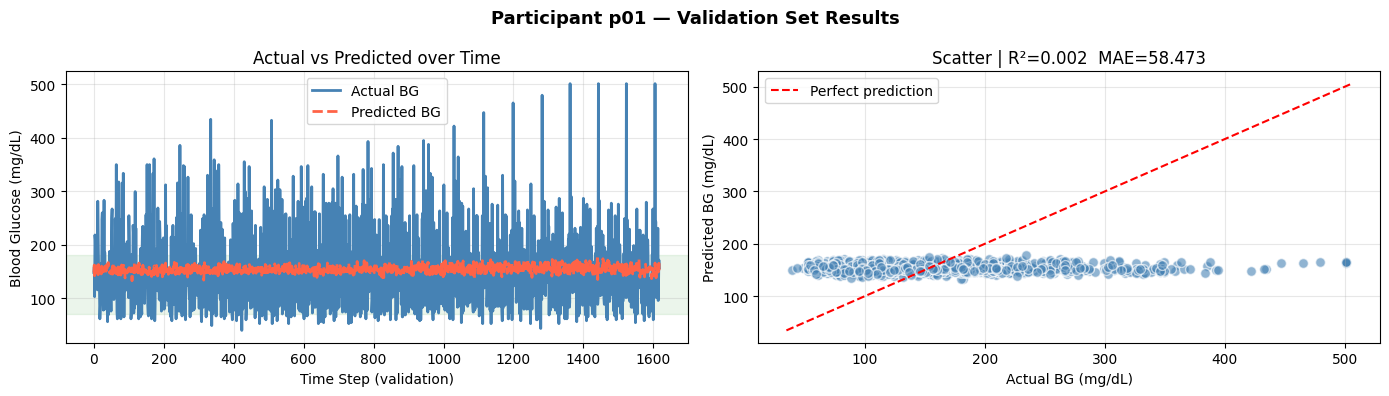

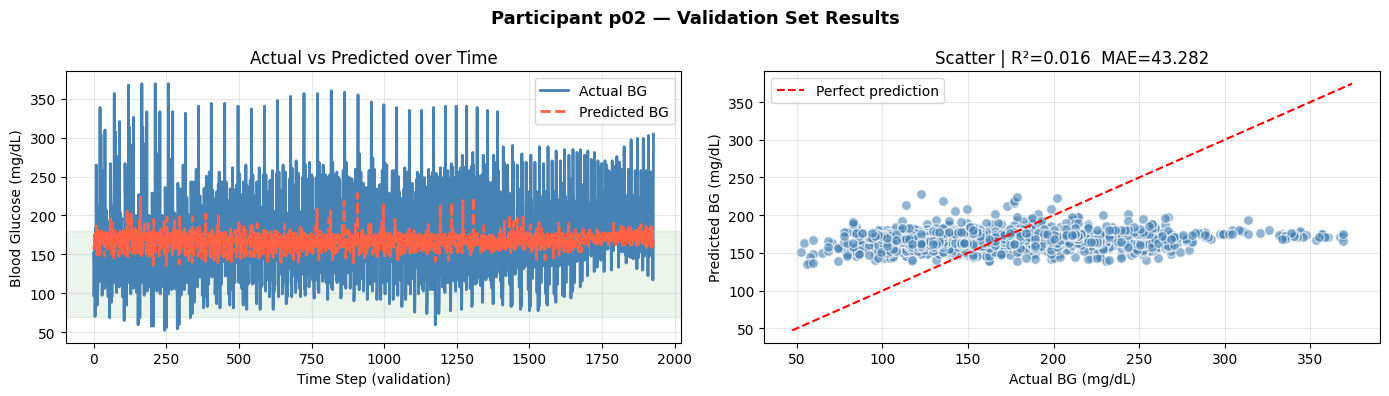

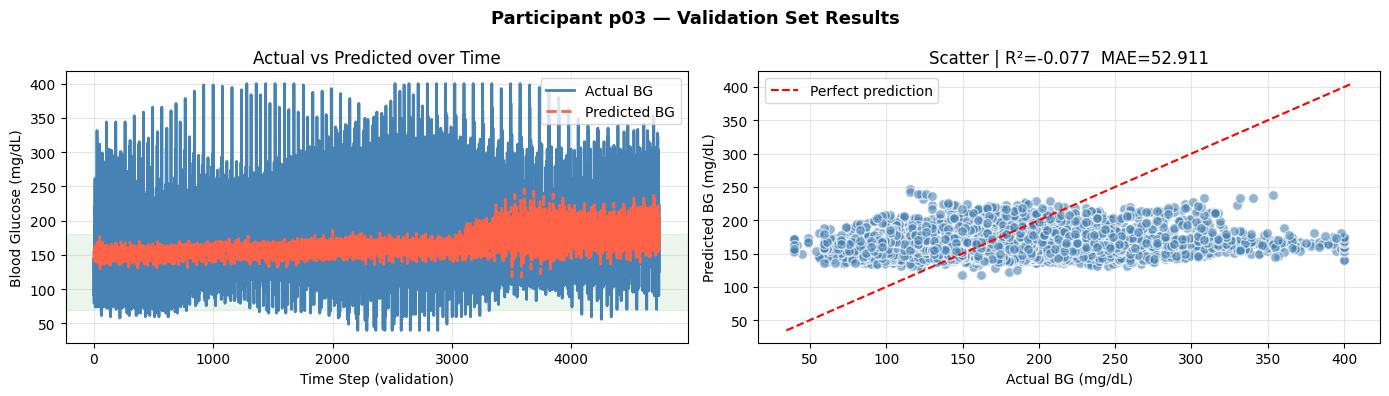

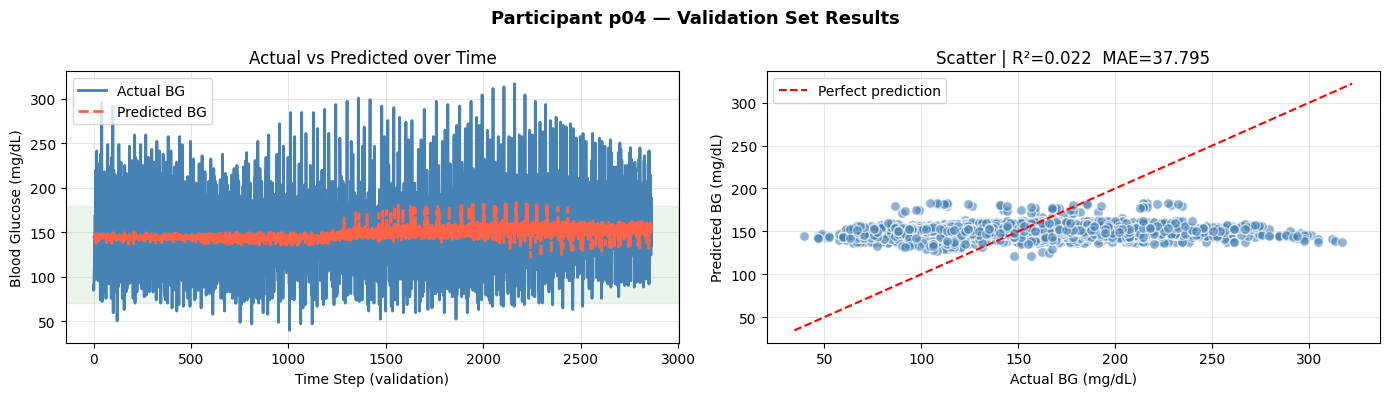

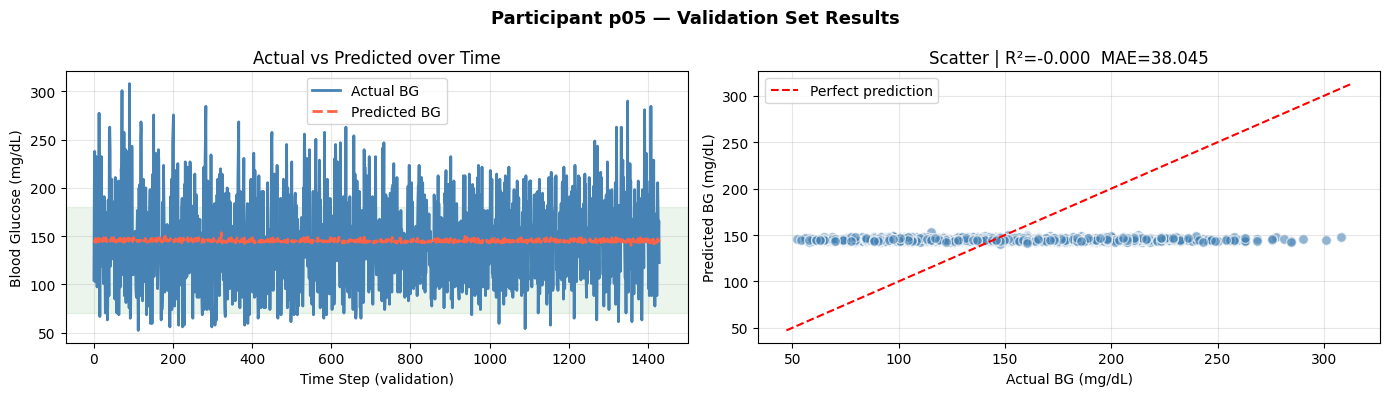

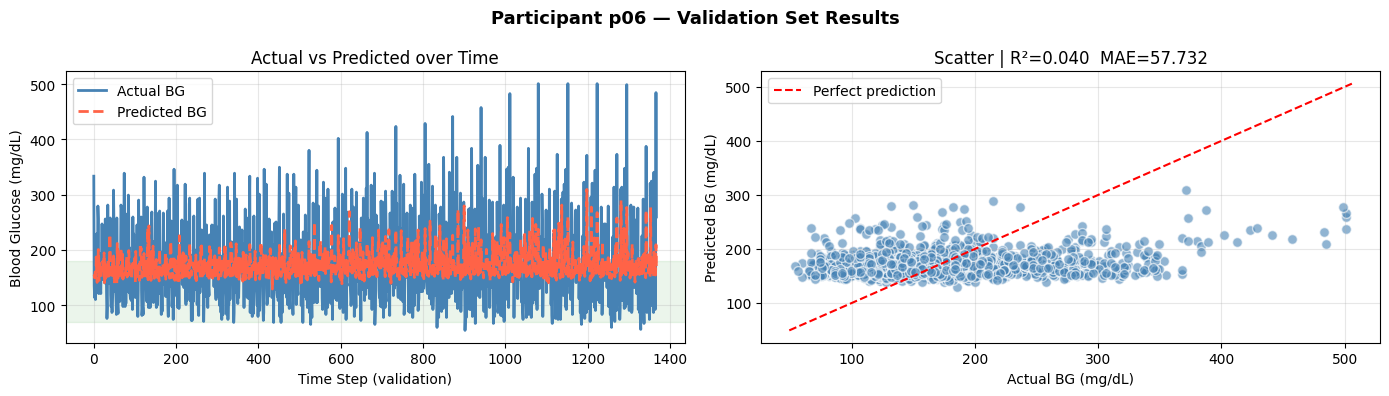

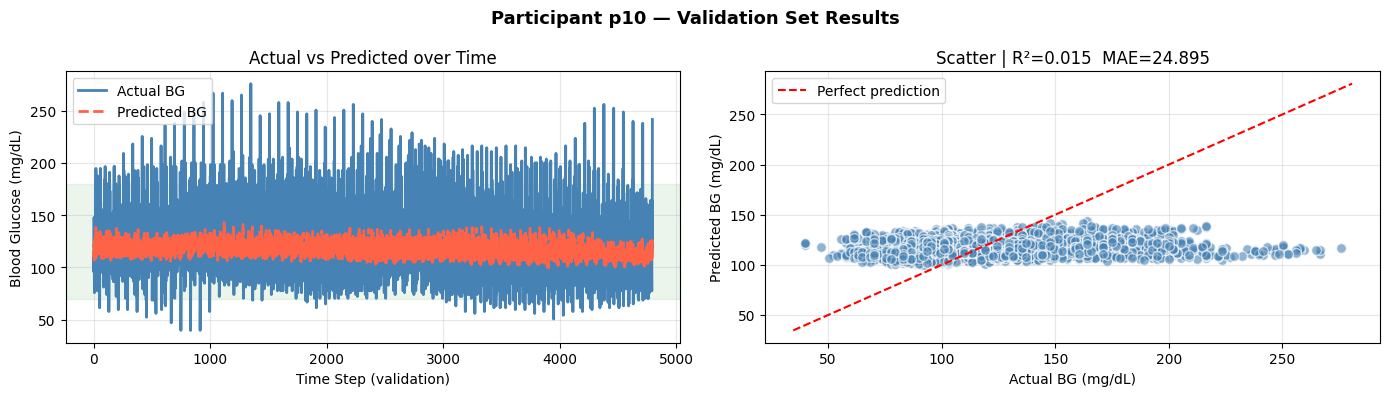

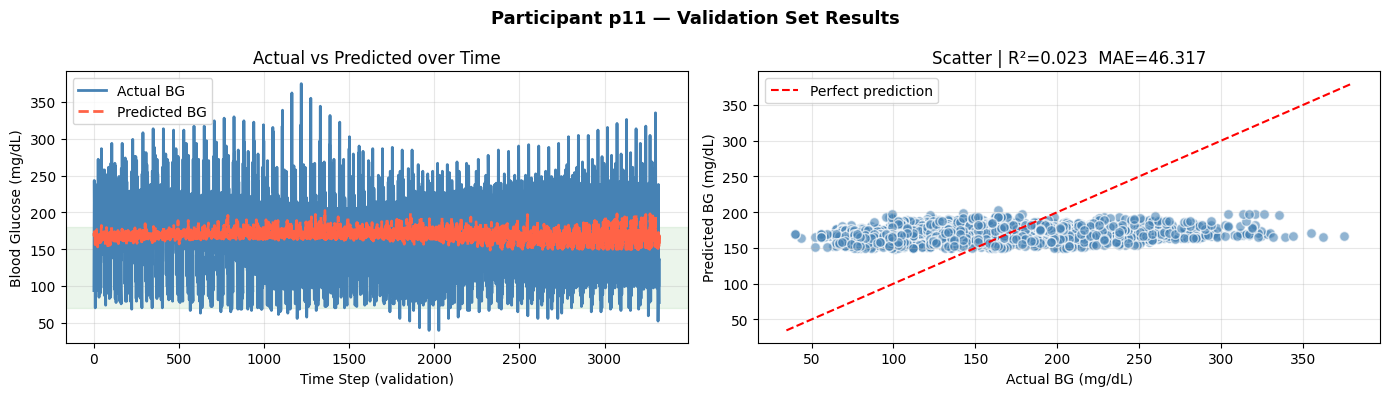

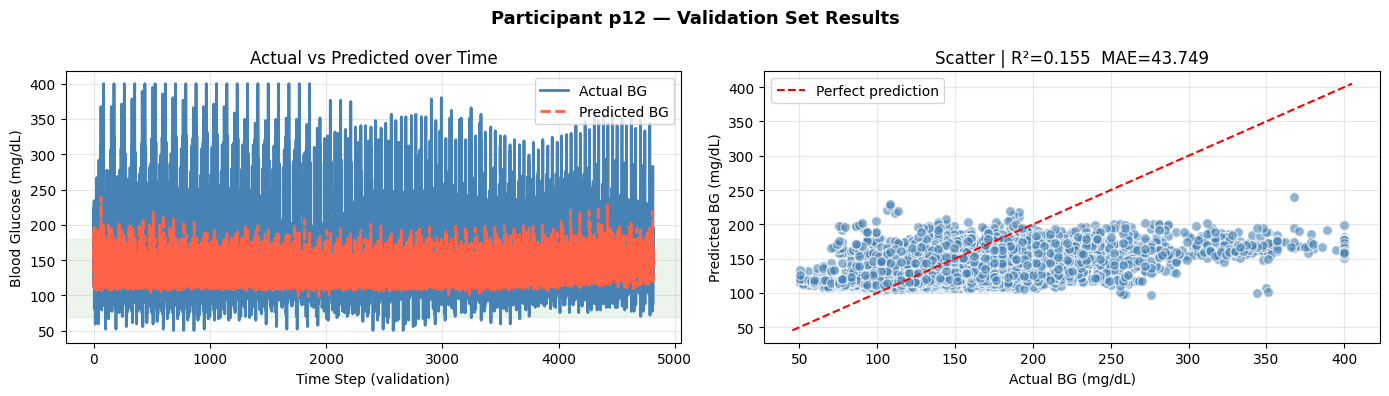

In [62]:
# ── Plot: Actual vs Predicted for each participant ──
for p_id, res in results.items():
    y_val      = res['y_val']
    y_pred_val = res['y_pred_val']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Participant {p_id} — Validation Set Results", fontsize=13, fontweight='bold')
    
    # --- Left: Time plot ---
    ax = axes[0]
    ax.plot(y_val, label='Actual BG', color='steelblue', linewidth=2)
    ax.plot(y_pred_val, label='Predicted BG', color='tomato', linewidth=2, linestyle='--')
    ax.set_xlabel('Time Step (validation)')
    ax.set_ylabel('Blood Glucose (mg/dL)')
    ax.set_title('Actual vs Predicted over Time')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Shade clinical target range 70–180 mg/dL (3.9–10 mmol/L)
    ax.axhspan(70, 180, alpha=0.08, color='green', label='Target range (70–180 mg/dL)')
    
    # --- Right: Scatter ---
    ax = axes[1]
    ax.scatter(y_val, y_pred_val, alpha=0.6, color='steelblue', edgecolors='white', s=50)
    lims = [min(y_val.min(), y_pred_val.min()) - 5,
            max(y_val.max(), y_pred_val.max()) + 5]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual BG (mg/dL)')
    ax.set_ylabel('Predicted BG (mg/dL)')
    ax.set_title(f"Scatter | R²={res['val_metrics']['r2']:.3f}  MAE={res['val_metrics']['mae']:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

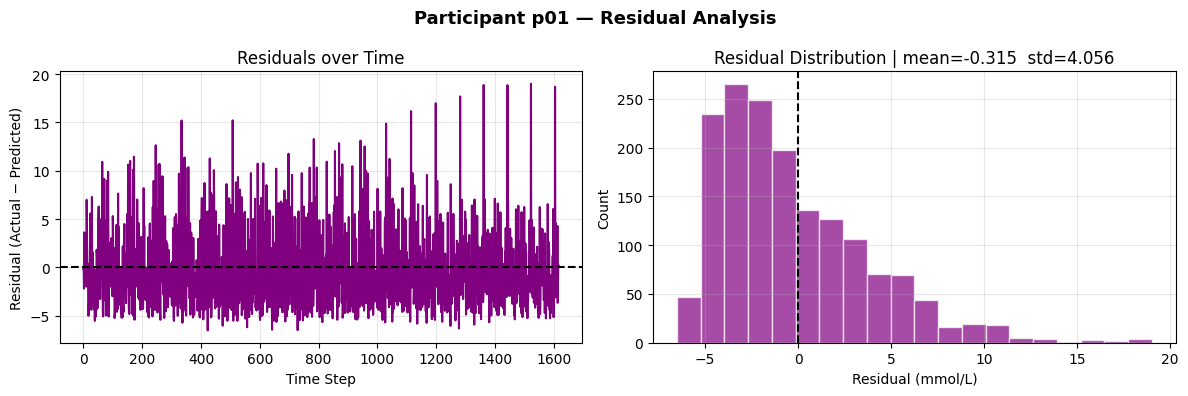

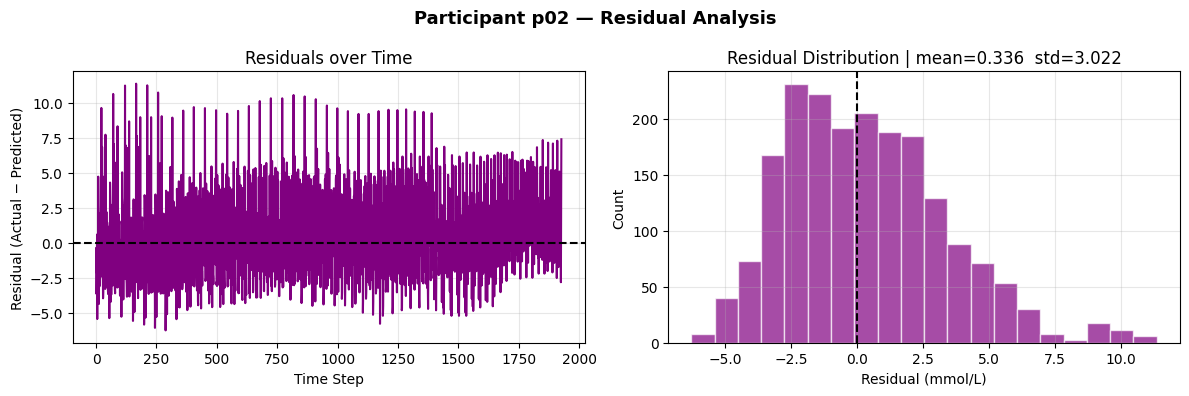

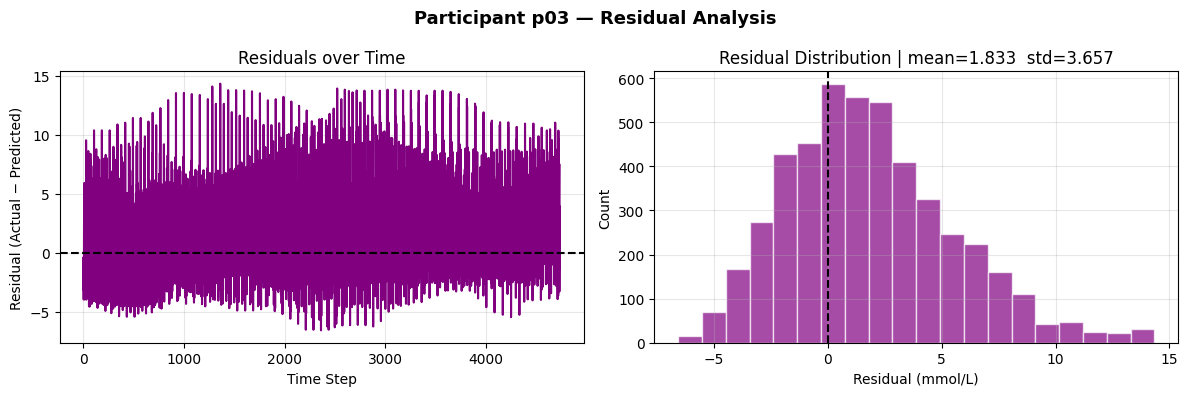

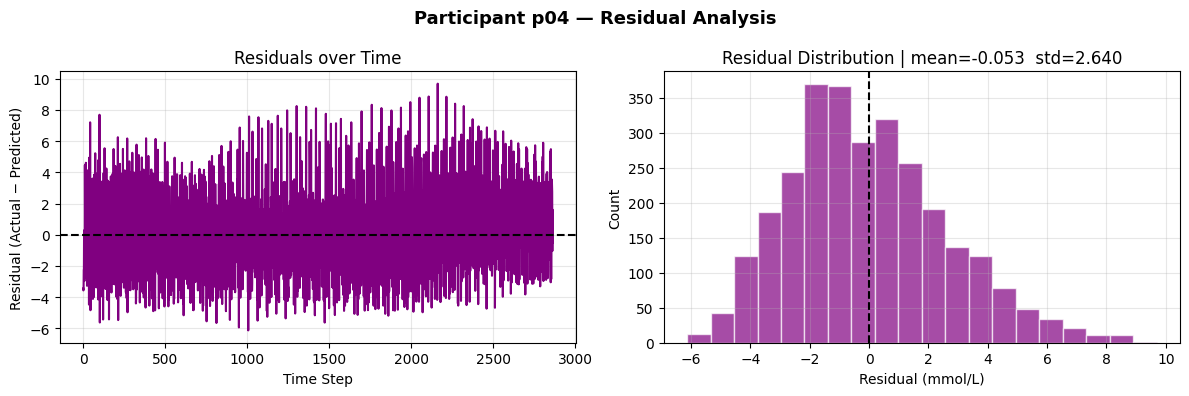

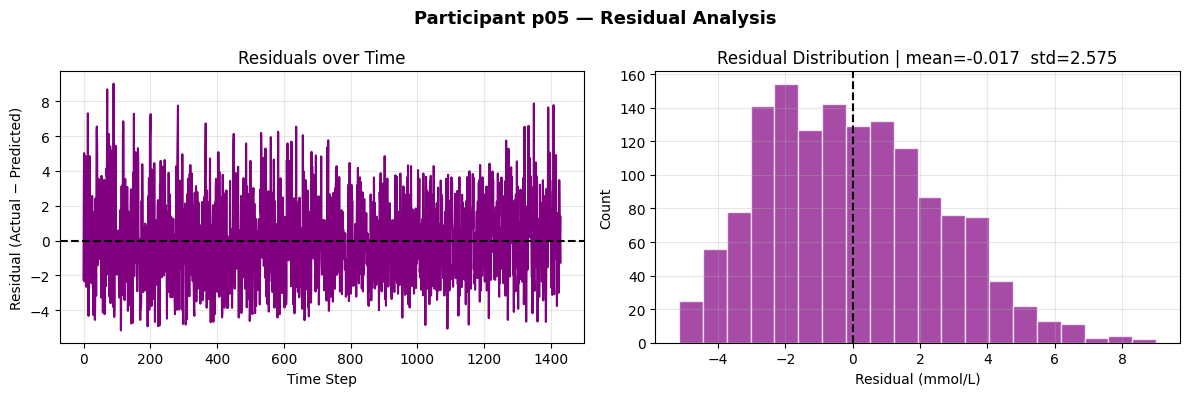

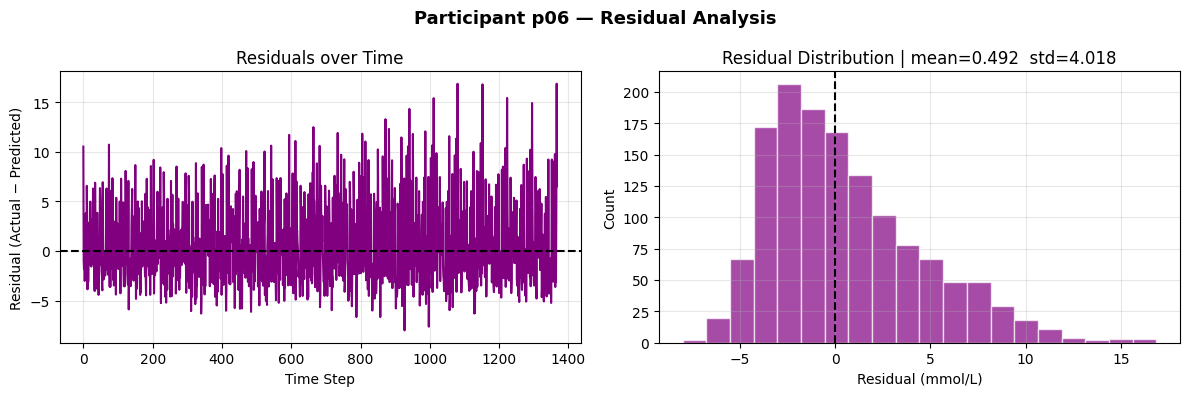

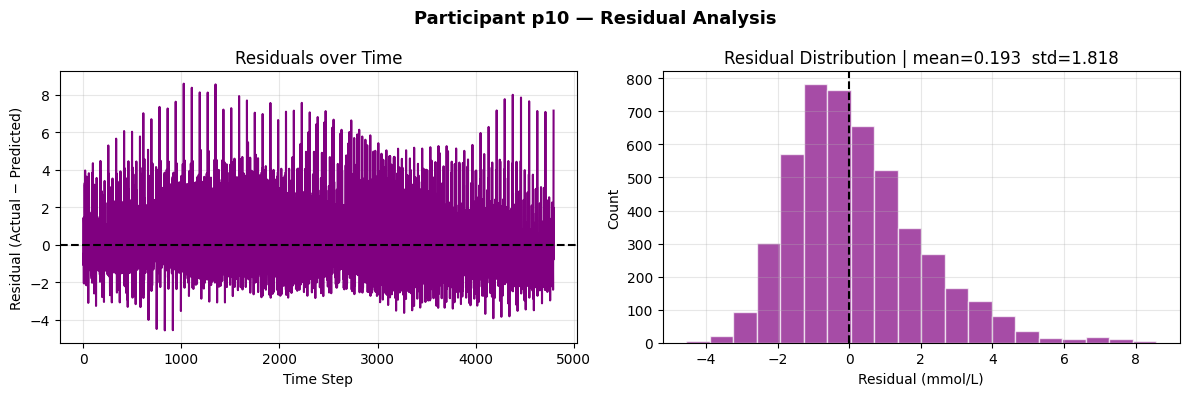

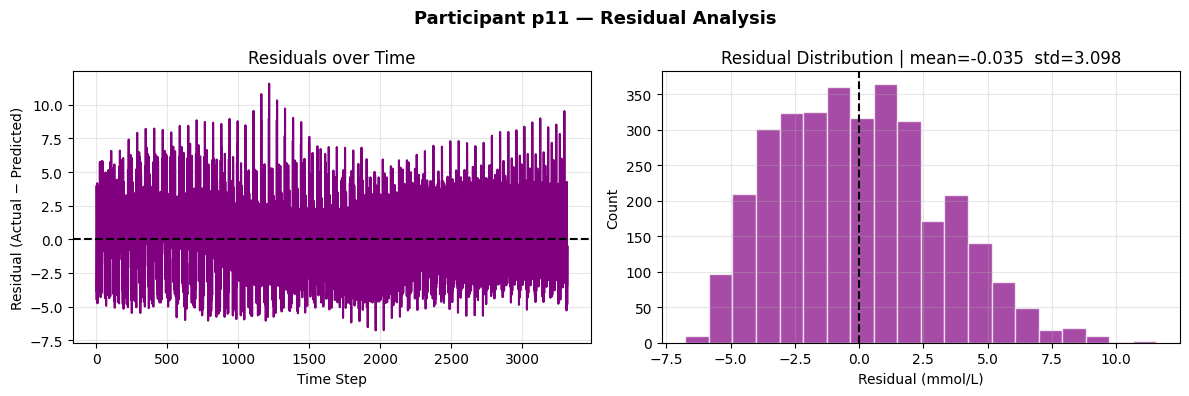

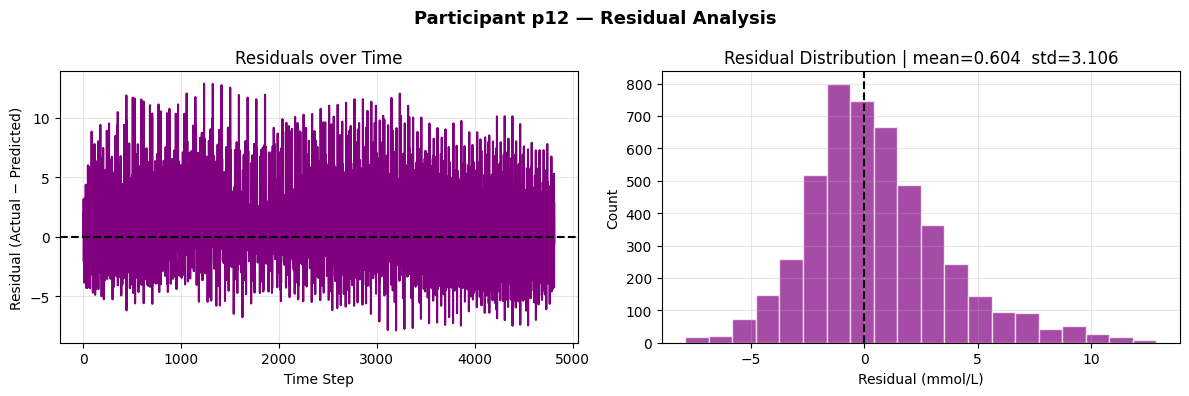

In [ ]:
# ── Residual plot (prediction errors) ──
for p_id, res in results.items():
    residuals = res['y_val'] - res['y_pred_val']
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Participant {p_id} — Residual Analysis", fontsize=13, fontweight='bold')
    
    # Residuals over time
    axes[0].plot(residuals, color='purple', linewidth=1.5)
    axes[0].axhline(0, color='black', linestyle='--')
    axes[0].set_xlabel('Time Step')
    axes[0].set_ylabel('Residual (Actual − Predicted) [mg/dL]')
    axes[0].set_title('Residuals over Time')
    axes[0].grid(alpha=0.3)
    
    # Histogram of residuals
    axes[1].hist(residuals, bins=20, color='purple', alpha=0.7, edgecolor='white')
    axes[1].axvline(0, color='black', linestyle='--')
    axes[1].set_xlabel('Residual (mg/dL)')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f"Residual Distribution | mean={residuals.mean():.3f}  std={residuals.std():.3f}")
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

---
## Step 8 — Performance Statistics & Feature Importance

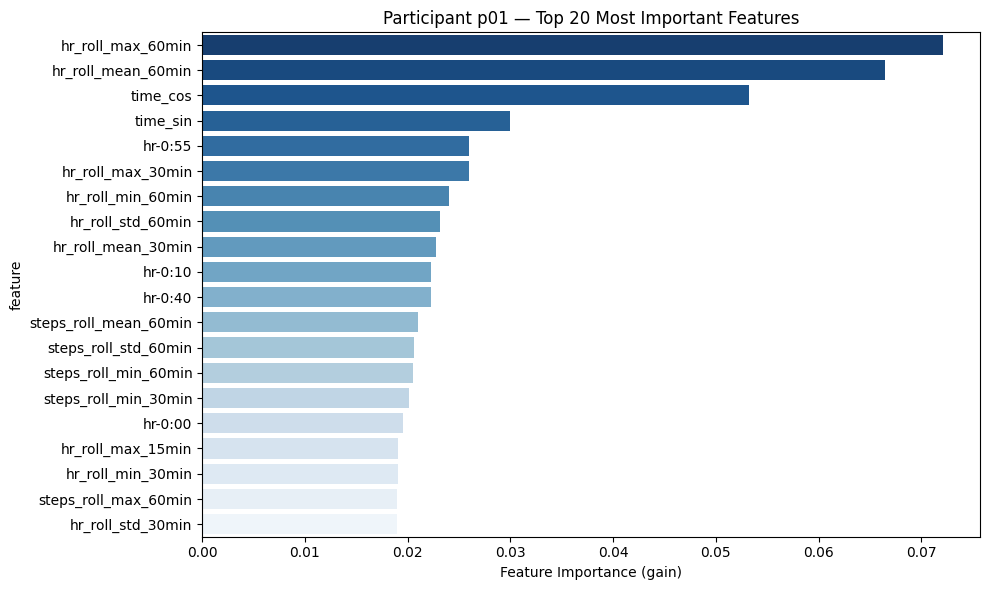


Top 10 features for p01:
           feature  importance
 hr_roll_max_60min    0.072110
hr_roll_mean_60min    0.066457
          time_cos    0.053215
          time_sin    0.029915
           hr-0:55    0.025980
 hr_roll_max_30min    0.025948
 hr_roll_min_60min    0.024023
 hr_roll_std_60min    0.023126
hr_roll_mean_30min    0.022753
           hr-0:10    0.022276


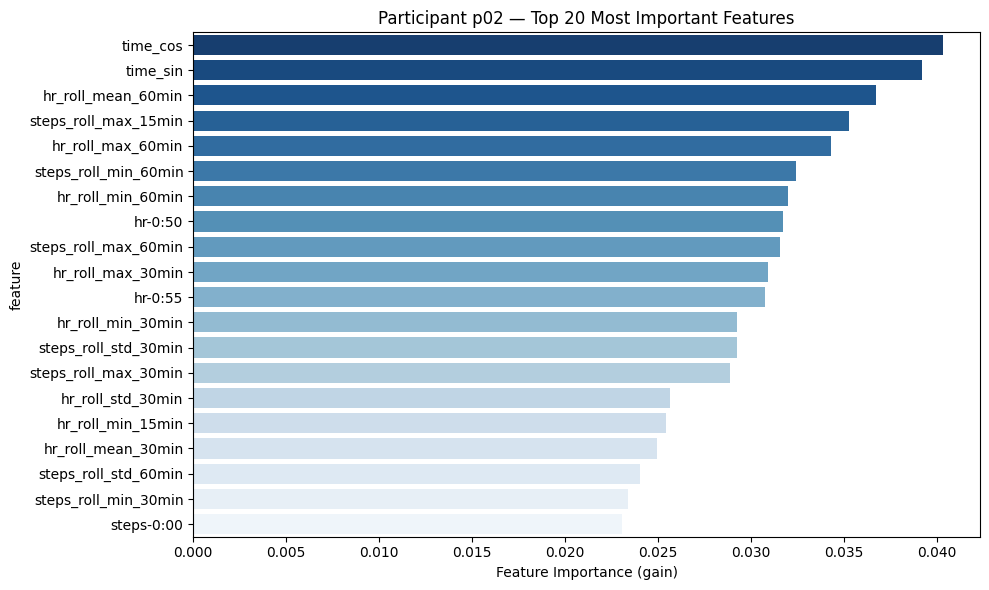


Top 10 features for p02:
             feature  importance
            time_cos    0.040325
            time_sin    0.039236
  hr_roll_mean_60min    0.036770
steps_roll_max_15min    0.035269
   hr_roll_max_60min    0.034320
steps_roll_min_60min    0.032444
   hr_roll_min_60min    0.031990
             hr-0:50    0.031731
steps_roll_max_60min    0.031567
   hr_roll_max_30min    0.030933


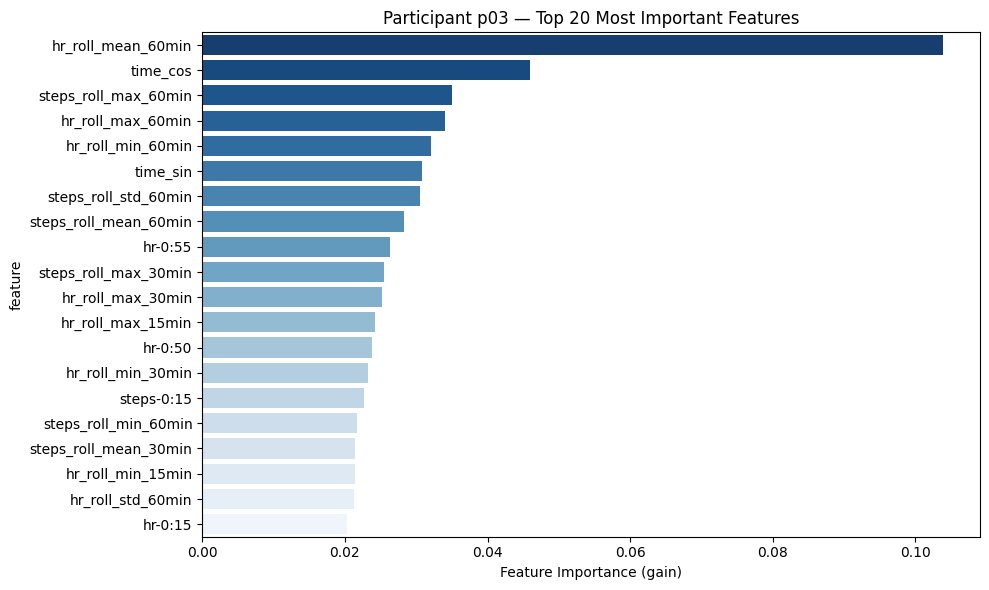


Top 10 features for p03:
              feature  importance
   hr_roll_mean_60min    0.103861
             time_cos    0.045972
 steps_roll_max_60min    0.035052
    hr_roll_max_60min    0.034084
    hr_roll_min_60min    0.032141
             time_sin    0.030823
 steps_roll_std_60min    0.030492
steps_roll_mean_60min    0.028310
              hr-0:55    0.026374
 steps_roll_max_30min    0.025427


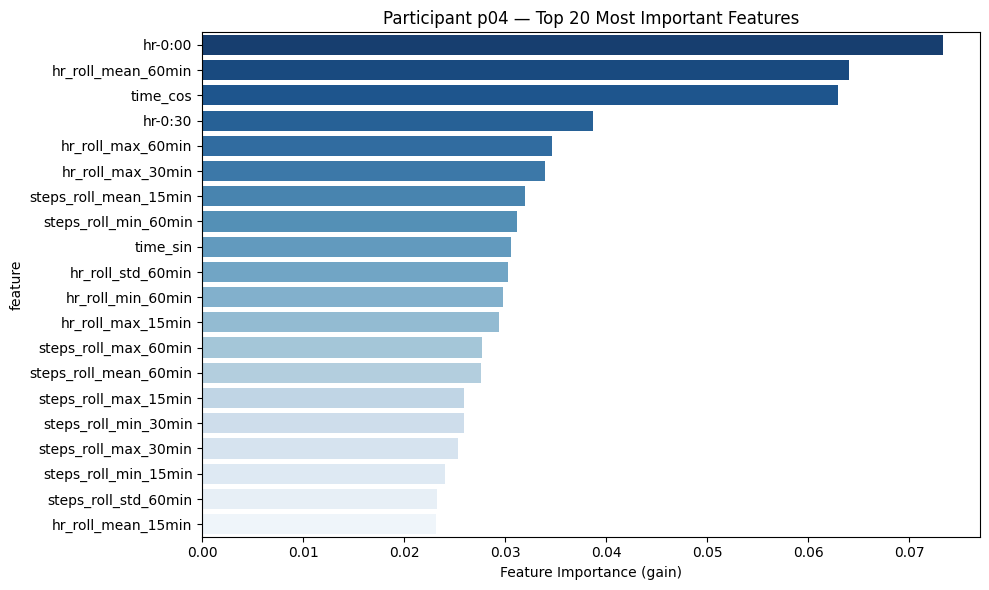


Top 10 features for p04:
              feature  importance
              hr-0:00    0.073335
   hr_roll_mean_60min    0.064046
             time_cos    0.062940
              hr-0:30    0.038649
    hr_roll_max_60min    0.034589
    hr_roll_max_30min    0.033940
steps_roll_mean_15min    0.031950
 steps_roll_min_60min    0.031154
             time_sin    0.030598
    hr_roll_std_60min    0.030275


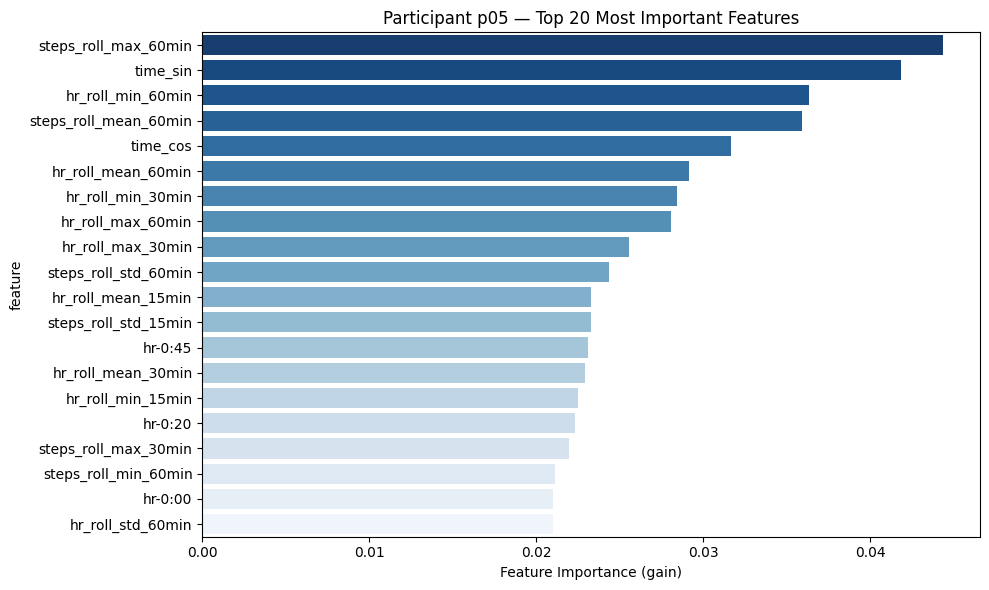


Top 10 features for p05:
              feature  importance
 steps_roll_max_60min    0.044374
             time_sin    0.041878
    hr_roll_min_60min    0.036351
steps_roll_mean_60min    0.035948
             time_cos    0.031646
   hr_roll_mean_60min    0.029164
    hr_roll_min_30min    0.028424
    hr_roll_max_60min    0.028063
    hr_roll_max_30min    0.025588
 steps_roll_std_60min    0.024362


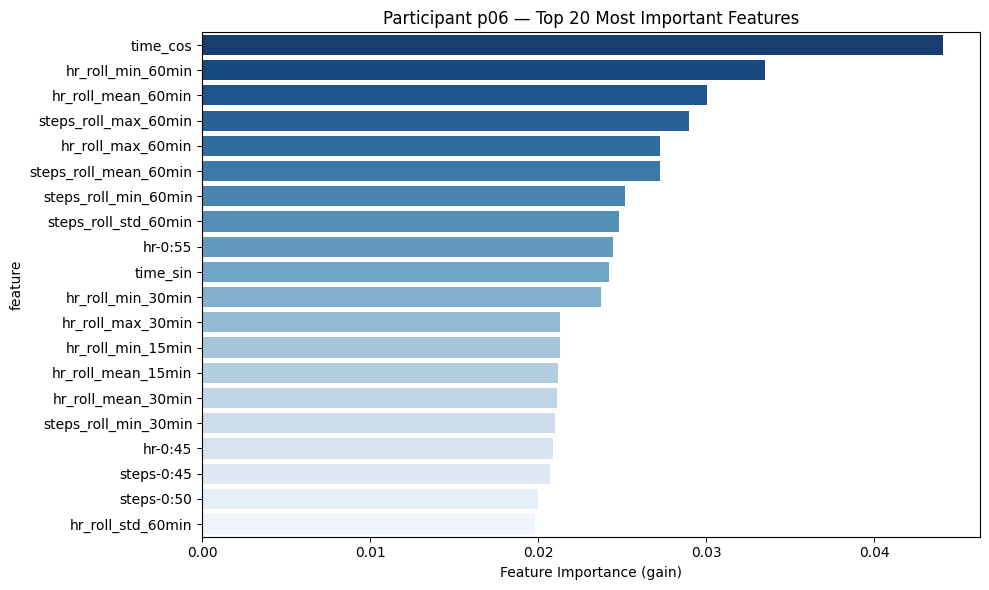


Top 10 features for p06:
              feature  importance
             time_cos    0.044093
    hr_roll_min_60min    0.033485
   hr_roll_mean_60min    0.030068
 steps_roll_max_60min    0.028980
    hr_roll_max_60min    0.027267
steps_roll_mean_60min    0.027223
 steps_roll_min_60min    0.025193
 steps_roll_std_60min    0.024823
              hr-0:55    0.024445
             time_sin    0.024189


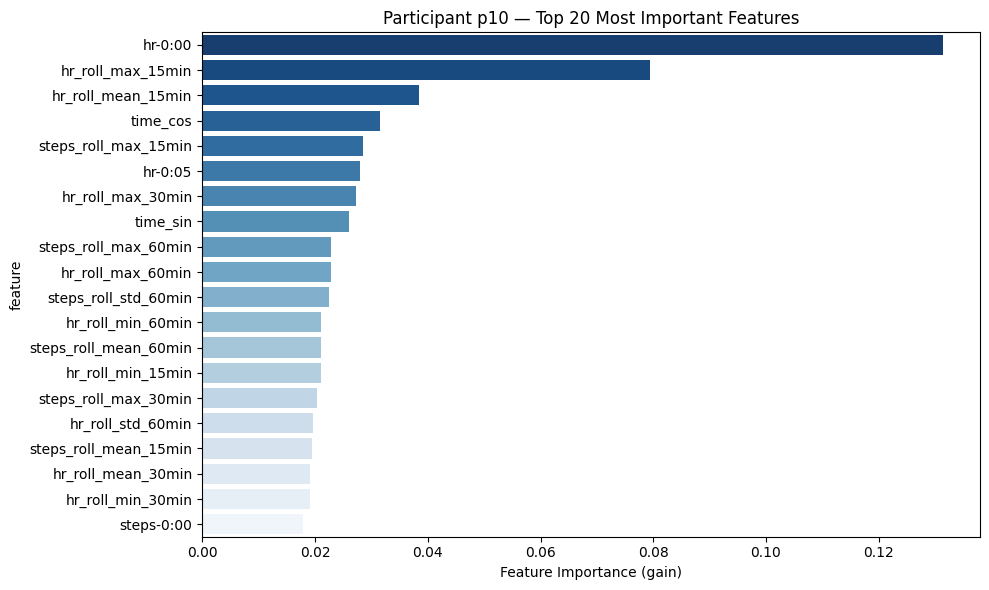


Top 10 features for p10:
             feature  importance
             hr-0:00    0.131395
   hr_roll_max_15min    0.079453
  hr_roll_mean_15min    0.038499
            time_cos    0.031498
steps_roll_max_15min    0.028492
             hr-0:05    0.027962
   hr_roll_max_30min    0.027284
            time_sin    0.026081
steps_roll_max_60min    0.022866
   hr_roll_max_60min    0.022761


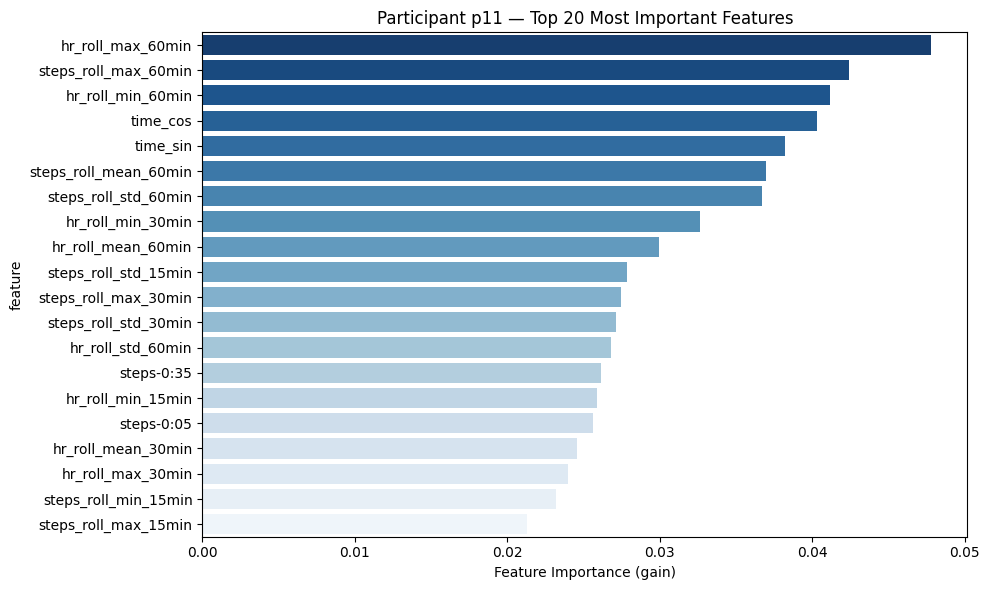


Top 10 features for p11:
              feature  importance
    hr_roll_max_60min    0.047791
 steps_roll_max_60min    0.042420
    hr_roll_min_60min    0.041149
             time_cos    0.040322
             time_sin    0.038238
steps_roll_mean_60min    0.036984
 steps_roll_std_60min    0.036717
    hr_roll_min_30min    0.032623
   hr_roll_mean_60min    0.029961
 steps_roll_std_15min    0.027850


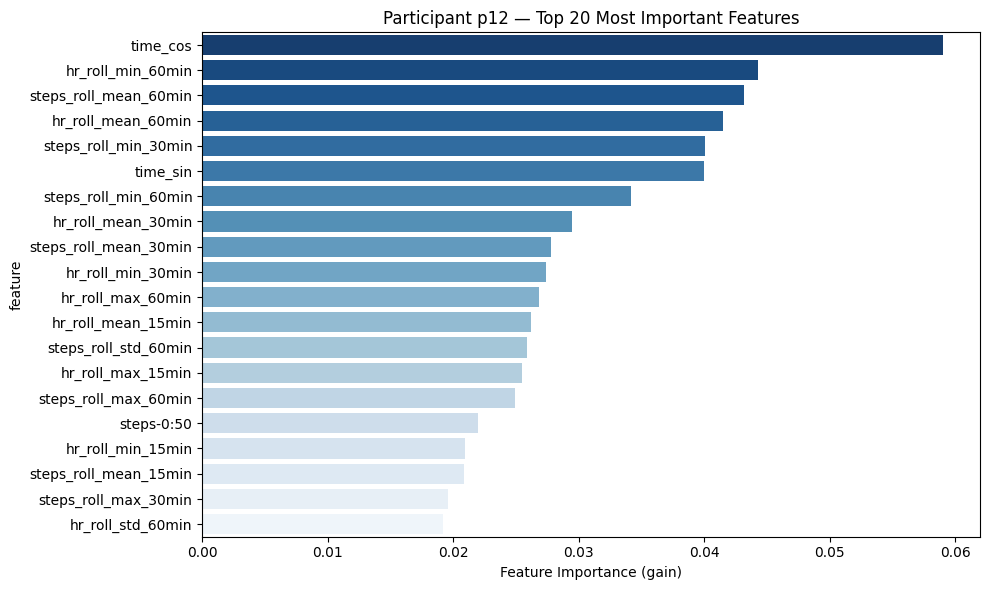


Top 10 features for p12:
              feature  importance
             time_cos    0.059018
    hr_roll_min_60min    0.044283
steps_roll_mean_60min    0.043162
   hr_roll_mean_60min    0.041463
 steps_roll_min_30min    0.040091
             time_sin    0.039943
 steps_roll_min_60min    0.034121
   hr_roll_mean_30min    0.029461
steps_roll_mean_30min    0.027824
    hr_roll_min_30min    0.027363


In [63]:
# ── Feature Importance ──
for p_id, model in models.items():
    importance = pd.DataFrame({
        'feature'   : FEATURE_COLS,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    top_n = 20
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=importance.head(top_n), x='importance', y='feature', palette='Blues_r', ax=ax)
    ax.set_title(f"Participant {p_id} — Top {top_n} Most Important Features")
    ax.set_xlabel('Feature Importance (gain)')
    plt.tight_layout()
    plt.show()
    
    print(f"\nTop 10 features for {p_id}:")
    print(importance.head(10).to_string(index=False))

In [ ]:
# ── Clinical Accuracy: % of predictions within ±18 and ±36 mg/dL ──
# This is more medically meaningful than just RMSE
# (18 mg/dL ≈ 1 mmol/L, 36 mg/dL ≈ 2 mmol/L)

print("=== Clinical Accuracy (Validation Set) ===")
for p_id, res in results.items():
    errors = np.abs(res['y_val'] - res['y_pred_val'])
    within_18 = (errors <= 18).mean() * 100
    within_36 = (errors <= 36).mean() * 100
    print(f"  {p_id}: {within_18:.1f}% within ±18 mg/dL | {within_36:.1f}% within ±36 mg/dL")
    print(f"         Mean error: {errors.mean():.1f} mg/dL | Max error: {errors.max():.1f} mg/dL")

=== Clinical Accuracy (Validation Set) ===
  p01: 16.6% within ±1 mmol/L | 31.5% within ±2 mmol/L
         Mean error: 3.263 mmol/L | Max error: 19.019 mmol/L
  p02: 22.9% within ±1 mmol/L | 47.5% within ±2 mmol/L
         Mean error: 2.416 mmol/L | Max error: 11.355 mmol/L
  p03: 22.0% within ±1 mmol/L | 41.8% within ±2 mmol/L
         Mean error: 3.122 mmol/L | Max error: 14.340 mmol/L
  p04: 27.0% within ±1 mmol/L | 55.2% within ±2 mmol/L
         Mean error: 2.127 mmol/L | Max error: 9.686 mmol/L
  p05: 26.3% within ±1 mmol/L | 51.3% within ±2 mmol/L
         Mean error: 2.113 mmol/L | Max error: 9.007 mmol/L
  p06: 20.1% within ±1 mmol/L | 38.3% within ±2 mmol/L
         Mean error: 3.142 mmol/L | Max error: 16.867 mmol/L
  p10: 44.7% within ±1 mmol/L | 76.7% within ±2 mmol/L
         Mean error: 1.398 mmol/L | Max error: 8.585 mmol/L
  p11: 22.3% within ±1 mmol/L | 44.8% within ±2 mmol/L
         Mean error: 2.548 mmol/L | Max error: 11.571 mmol/L
  p12: 29.6% within ±1 mmol/L | 

In [64]:
# ── Clarke Error Grid Analysis (simplified version) ──
# This is a standard clinical tool for evaluating BG predictions
# Zone A = clinically accurate, Zone B = acceptable, C/D/E = dangerous

def clarke_error_grid_zones(actual, predicted):
    """Simplified Clarke Error Grid zone assignment (mg/dL)."""
    zones = []
    for a, p in zip(actual, predicted):
        if (abs(a - p) / max(a, 0.001)) <= 0.20:
            zones.append('A')  # within 20% — clinically accurate
        elif (a < 70 and p < 70) or (a > 180 and p > 180):
            zones.append('B')  # both in same abnormal region — acceptable
        elif abs(a - p) <= 36:
            zones.append('B')  # within 36 mg/dL (~2 mmol/L) — acceptable
        else:
            zones.append('C+') # potentially dangerous
    return np.array(zones)

print("=== Simplified Clarke Error Grid Analysis (Validation) ===")
for p_id, res in results.items():
    zones = clarke_error_grid_zones(res['y_val'], res['y_pred_val'])
    for z in ['A', 'B', 'C+']:
        pct = (zones == z).mean() * 100
        print(f"  {p_id} Zone {z}: {pct:.1f}%")

=== Simplified Clarke Error Grid Analysis (Validation) ===
  p01 Zone A: 26.3%
  p01 Zone B: 6.7%
  p01 Zone C+: 67.0%
  p02 Zone A: 45.7%
  p02 Zone B: 8.1%
  p02 Zone C+: 46.2%
  p03 Zone A: 40.8%
  p03 Zone B: 7.2%
  p03 Zone C+: 52.1%
  p04 Zone A: 46.2%
  p04 Zone B: 10.3%
  p04 Zone C+: 43.5%
  p05 Zone A: 42.5%
  p05 Zone B: 8.9%
  p05 Zone C+: 48.6%
  p06 Zone A: 33.3%
  p06 Zone B: 11.3%
  p06 Zone C+: 55.4%
  p10 Zone A: 57.5%
  p10 Zone B: 19.6%
  p10 Zone C+: 22.9%
  p11 Zone A: 42.7%
  p11 Zone B: 6.0%
  p11 Zone C+: 51.3%
  p12 Zone A: 43.1%
  p12 Zone B: 14.6%
  p12 Zone C+: 42.2%


---
## Step 9 — Experimentation Guide

Now that the baseline is running, here are things to try for your FYP:

### 🔬 Feature Experiments
- Change `LOOKBACK_STEPS` (e.g. 6 = 30 min, 12 = 1hr, 24 = 2hr) and compare results
- Add more rolling windows (e.g. `windows=[3, 6, 12, 24]`)
- Try HR trend: `hr-0:00` minus `hr-0:30` (is HR rising or falling?)
- Add cyclic time features:
  ```python
  df['hour_sin'] = np.sin(2 * np.pi * df['time_seconds'] / 86400)
  df['hour_cos'] = np.cos(2 * np.pi * df['time_seconds'] / 86400)
  ```

### 🧠 Model Experiments
- Try different `max_depth` values (3, 5, 7) — shallower = less overfitting
- Try different `learning_rate` (0.01 = slow/careful, 0.1 = faster)
- Compare personalized vs. global model (train on all participants combined)

### 📊 Evaluation Extras
- Plot learning curves (train vs val MAE across iterations)
- Use cross-validation with `TimeSeriesSplit` from sklearn for more robust estimates
- Add confidence intervals (XGBoost doesn't natively support them, but you can use quantile regression)

### ⚙️ Hyperparameter Tuning
```python
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.01, 0.05, 0.1],
    'n_estimators'  : [100, 200, 300],
}
tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(XGBRegressor(), param_grid, cv=tscv, scoring='neg_mean_absolute_error')
grid.fit(X_train, y_train)
print(grid.best_params_)
```

In [ ]:
# ── Optional: Learning curve (train vs val loss per tree) ──
for p_id, res in results.items():
    model = res['model']
    evals = model.evals_result()
    
    if 'validation_0' not in evals:
        continue
    
    val_rmse = evals['validation_0']['rmse']
    
    plt.figure(figsize=(9, 4))
    plt.plot(val_rmse, label='Validation RMSE', color='tomato')
    plt.axvline(model.best_iteration, color='navy', linestyle='--', label=f'Best iter={model.best_iteration}')
    plt.xlabel('Boosting Round')
    plt.ylabel('RMSE')
    plt.title(f"{p_id} — XGBoost Learning Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
print("🎉 Complete! Your personalized XGBoost BG prediction model is trained and evaluated.")
print("Next steps: experiment with LOOKBACK_STEPS, rolling windows, and hyperparameters.")